# TPV Route Planning

Route optimisation for airborne meteorological surveys of Tropopause Polar Vortex (TPV) systems.

**Mission:** BASE → transit → observe TPV interior (parallel chords ⊥ major axis) → satellite coincidence segment → return to BASE

**Dependencies:** `numpy` `matplotlib` `shapely` `geopandas`

---

## Module structure

| Module | Cells | Content |
|--------|-------|---------|
| **1** | this file | Geometry utilities · PCA ellipse fit · candidate chord generation |
| 2 | — | Obstacle avoidance (Restricted Airspace) · Visibility graph · ATC zone penalty |
| 3 | — | Satellite coincidence segment · departure-time scheduling |
| 4 | — | Full route optimisation · dropsonde zone scoring · output |

All tunable parameters are defined at the top of the **Parameters** cell.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Polygon, Point
from math import cos, sin, sqrt, pi, radians, degrees, atan2
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════════════
# TUNABLE PARAMETERS  —  edit here only
# ════════════════════════════════════════════════════════════════════════════

AIRCRAFT_SPEED_KMH  = 850.0   # G3 cruise speed (km/h)
FLIGHT_TIME_H       = 5.0     # total mission time budget, including transit (hours)
TOTAL_BUDGET_KM     = AIRCRAFT_SPEED_KMH * FLIGHT_TIME_H   # 4 250 km

ATC_PENALTY_FACTOR  = 1.35    # effective-distance multiplier inside ATC zones (range 1.25–1.5)
TURN_PENALTY_MIN    = 7.5     # time penalty per heading change (minutes, range 5–10)
TURN_PENALTY_KM     = TURN_PENALTY_MIN / 60.0 * AIRCRAFT_SPEED_KMH   # ≈ 106 km

MIN_LEG_SPACING_KM  = 50.0   # minimum spacing between parallel observation legs  [TBD — confirm with scientist]
MAX_ANGLE_DEV_DEG   = 20.0   # max allowed chord-direction deviation from ideal    [TBD]
N_ANGLE_SAMPLES     = 5      # number of angle-deviation samples within ±MAX_ANGLE_DEV_DEG

T_MIN_SAT_MIN       = 10.0   # minimum satellite coincidence time (minutes)

# ════════════════════════════════════════════════════════════════════════════
print(f'Total budget      : {TOTAL_BUDGET_KM:.0f} km')
print(f'Turn penalty      : {TURN_PENALTY_KM:.0f} km / turn')
print(f'Min leg spacing   : {MIN_LEG_SPACING_KM:.0f} km')
print(f'Angle deviation   : ±{MAX_ANGLE_DEV_DEG:.0f}° ({N_ANGLE_SAMPLES} samples)')

Total budget      : 4250 km
Turn penalty      : 106 km / turn
Min leg spacing   : 50 km
Angle deviation   : ±20° (5 samples)


## Module 1 — Geometry utilities

All geometric operations use **shapely** so the code runs with a standard `pip install` and is independent of ArcGIS.

| Function | Purpose |
|----------|---------|
| `fit_pca_ellipse` | Fit a 2-D ellipse to polygon vertices via PCA; returns center, semi-axes a ≥ b, orientation φ |
| `chord_in_polygon` | Intersect an infinite line with a shapely Polygon; return the two boundary crossing points and chord length |
| `generate_candidate_chords` | Enumerate all candidate observation chords (direction ≈ minor axis, evenly spaced along major axis) |
| `straight_dist` | Straight-line distance between two points — obstacle avoidance is added in Module 2 |

In [2]:
def rot2d(angle_rad):
    c, s = cos(angle_rad), sin(angle_rad)
    return np.array([[c, -s], [s, c]])


def fit_pca_ellipse(pts):
    """PCA ellipse fit.
    Returns (center, a, b, phi): centroid (km), major semi-axis a (km),
    minor semi-axis b (km), major-axis orientation phi (radians).
    """
    pts = np.asarray(pts, float)
    center = pts.mean(axis=0)
    cov = np.cov((pts - center).T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    a   = 2.0 * sqrt(max(eigvals[0], 0.))
    b   = 2.0 * sqrt(max(eigvals[1], 0.))
    phi = atan2(eigvecs[1, 0], eigvecs[0, 0])
    return center, a, b, phi


def chord_in_polygon(offset_pt, direction, poly, far=2e4):
    """Chord of the line through offset_pt in direction inside shapely Polygon poly.

    Uses shapely intersection — works correctly for non-convex polygons.
    Returns (pt_a, pt_b, length_km) where pt_a is in the positive-direction half,
    or None if the line does not cross the polygon.
    """
    p = np.asarray(offset_pt, float)
    d = np.asarray(direction,  float)
    d = d / np.linalg.norm(d)

    line    = LineString([p - far * d, p + far * d])
    segment = poly.intersection(line)

    if segment.is_empty:
        return None

    # Non-convex polygon may yield multiple disconnected pieces; take the longest
    if segment.geom_type == 'MultiLineString':
        segment = max(segment.geoms, key=lambda g: g.length)

    if segment.geom_type != 'LineString' or segment.length < 0.5:
        return None

    coords = np.array(segment.coords)
    pt_a, pt_b = coords[0], coords[-1]
    # pt_a: smaller t (entry if flying in +d direction)
    if np.dot(pt_a - p, d) > np.dot(pt_b - p, d):
        pt_a, pt_b = pt_b, pt_a
    return pt_a, pt_b, float(segment.length)


def generate_candidate_chords(tpv_poly, center, a, phi,
                               min_spacing=MIN_LEG_SPACING_KM,
                               angle_devs_deg=None):
    """Enumerate candidate observation chords through tpv_poly (shapely Polygon).

    Direction: minor axis (phi + 90°) ± each value in angle_devs_deg.
    Positions: evenly spaced along major axis at intervals of min_spacing km.

    Returns list of dicts: {pt_a, pt_b, length, offset, angle_dev, direction}.
    pt_a / pt_b are the two boundary crossing points (numpy arrays, km).
    Entry/exit are assigned later during route optimisation.
    """
    if angle_devs_deg is None:
        angle_devs_deg = [0]

    major   = np.array([cos(phi), sin(phi)])
    n_steps = max(1, int(2.0 * a / min_spacing)) + 1
    offsets = np.linspace(-a * 0.95, a * 0.95, n_steps)

    chords = []
    for dev in angle_devs_deg:
        chord_angle = phi + pi / 2 + radians(dev)
        direction   = np.array([cos(chord_angle), sin(chord_angle)])
        for d in offsets:
            pt = np.asarray(center) + d * major
            result = chord_in_polygon(pt, direction, tpv_poly)
            if result is None:
                continue
            pt_a, pt_b, length = result
            chords.append(dict(
                pt_a=pt_a, pt_b=pt_b, length=length,
                offset=float(d), angle_dev=dev, direction=direction.copy()
            ))
    return chords


def straight_dist(p, q):
    """Straight-line distance (km). Obstacle avoidance is added in Module 2."""
    return float(np.linalg.norm(np.asarray(q, float) - np.asarray(p, float)))


print('Utilities loaded.')

Utilities loaded.


## Synthetic test data

A noisy closed polygon (100 vertices) stands in for a real TPV contour.
True semi-axes: a = 200 km, b = 120 km, orientation = 30°.  
BASE is placed ~979 km from the centroid (GOOSE BAY scale).

**To use real data:** replace `TPV_PTS` with vertices loaded from a shapefile via geopandas, and set `BASE` to the actual base coordinates in the same local km frame.

In [3]:
np.random.seed(42)
A_TRUE   = 200.            # km, true major semi-axis
B_TRUE   = 120.            # km, true minor semi-axis
PHI_TRUE = radians(30.)    # true orientation

th     = np.linspace(0, 2*pi, 101)[:-1]          # 100 vertices
R_true = rot2d(PHI_TRUE)
noise  = np.random.randn(100, 2) * 10.            # ±10 km boundary irregularity
TPV_PTS = (R_true @ np.vstack([A_TRUE*np.cos(th),
                                B_TRUE*np.sin(th)])).T + noise

# shapely Polygon — .buffer(0) fixes any self-intersections from noise
tpv_poly = Polygon(TPV_PTS).buffer(0)

BASE = np.array([-700., 600.])   # km from TPV centroid  (replace with real coords)

d_transit_one_way = straight_dist(BASE, TPV_PTS.mean(axis=0))
d_transit_rt      = 2.0 * d_transit_one_way

print(f'TPV polygon         : {len(TPV_PTS)} vertices')
print(f'Extent              : {TPV_PTS[:,0].ptp():.0f} × {TPV_PTS[:,1].ptp():.0f} km')
print(f'BASE → centroid     : {d_transit_one_way:.0f} km')
print(f'Round-trip transit  : {d_transit_rt:.0f} km  of {TOTAL_BUDGET_KM:.0f} km budget')
print(f'Budget after transit: {TOTAL_BUDGET_KM - d_transit_rt:.0f} km  available for observation')

TPV polygon         : 100 vertices
Extent              : 377 × 319 km
BASE → centroid     : 921 km
Round-trip transit  : 1842 km  of 4250 km budget
Budget after transit: 2408 km  available for observation


## PCA ellipse fit

The PCA ellipse gives:
- **φ** (major axis orientation) → the direction chords should be perpendicular to
- **a, b** (semi-axes) → the range of valid chord offsets along the major axis

The minor axis direction **φ + 90°** is the ideal chord direction.

PCA fit :  a = 284.2 km   b = 169.9 km   φ = -150.5°
True    :  a = 200.0 km   b = 120.0 km   φ = 30.0°
Ideal chord direction (minor axis): (0.492, -0.871)


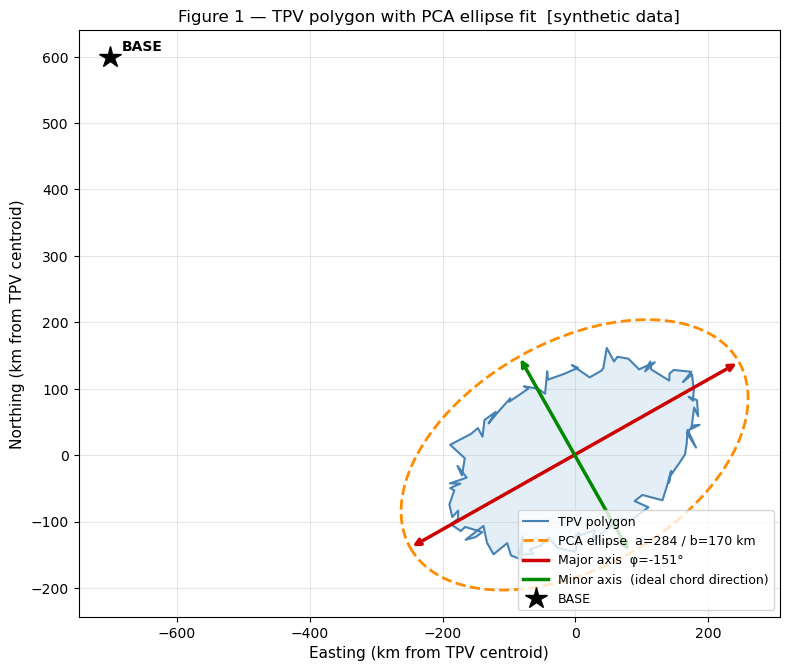

In [4]:
center, a_fit, b_fit, phi_fit = fit_pca_ellipse(TPV_PTS)

print(f'PCA fit :  a = {a_fit:.1f} km   b = {b_fit:.1f} km   φ = {degrees(phi_fit):.1f}°')
print(f'True    :  a = {A_TRUE:.1f} km   b = {B_TRUE:.1f} km   φ = {degrees(PHI_TRUE):.1f}°')

major_dir = np.array([cos(phi_fit),          sin(phi_fit)])
minor_dir = np.array([cos(phi_fit + pi/2),   sin(phi_fit + pi/2)])
print(f'Ideal chord direction (minor axis): '
      f'({minor_dir[0]:.3f}, {minor_dir[1]:.3f})')

# Ellipse outline for plotting
R_fit  = rot2d(phi_fit)
th_e   = np.linspace(0, 2*pi, 300)
ell_xy = (R_fit @ np.vstack([a_fit*np.cos(th_e),
                              b_fit*np.sin(th_e)])).T + center

# ── Figure 1: TPV polygon + PCA ellipse ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))

closed = np.vstack([TPV_PTS, TPV_PTS[0]])
ax.fill(TPV_PTS[:,0], TPV_PTS[:,1], color='#cfe0f0', alpha=0.55, zorder=1)
ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.5,
        zorder=2, label='TPV polygon')
ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=2,
        zorder=3, label=f'PCA ellipse  a={a_fit:.0f} / b={b_fit:.0f} km')

for vec, col, lbl in [
    (major_dir * a_fit, '#cc0000', f'Major axis  φ={degrees(phi_fit):.0f}°'),
    (minor_dir * b_fit, '#008800', 'Minor axis  (ideal chord direction)'),
]:
    ax.annotate('', xy=center+vec, xytext=center-vec,
                arrowprops=dict(arrowstyle='<->', color=col, lw=2.5))
    ax.plot([], [], color=col, lw=2.5, label=lbl)

ax.plot(*BASE, '*', color='black', ms=16, zorder=7, label='BASE')
ax.annotate('BASE', BASE, textcoords='offset points',
            xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlabel('Easting (km from TPV centroid)', fontsize=11)
ax.set_ylabel('Northing (km from TPV centroid)', fontsize=11)
ax.set_title('Figure 1 — TPV polygon with PCA ellipse fit  [synthetic data]',
             fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Candidate chord generation and budget feasibility

Chords are generated for `N_ANGLE_SAMPLES` directions spanning ±`MAX_ANGLE_DEV_DEG` around the ideal minor-axis direction.
Along the major axis, positions are spaced `MIN_LEG_SPACING_KM` apart.

**Budget feasibility** (straight-line, no obstacles yet):
```
single_trip = dist(BASE → pt_a) + chord length + dist(pt_b → BASE)
remaining   = TOTAL_BUDGET_KM − single_trip
```
A positive `remaining` means there is budget left for a second transect or satellite coincidence.

In [5]:
angle_devs = np.linspace(-MAX_ANGLE_DEV_DEG, MAX_ANGLE_DEV_DEG,
                          N_ANGLE_SAMPLES).tolist()

chords = generate_candidate_chords(
    tpv_poly, center, a_fit, phi_fit,
    min_spacing=MIN_LEG_SPACING_KM,
    angle_devs_deg=angle_devs
)

# Budget feasibility — straight-line transit, single chord (no obstacles)
for c in chords:
    # Both orientations of the chord: aircraft may approach from either end
    d_fwd = straight_dist(BASE, c['pt_a']) + c['length'] + straight_dist(c['pt_b'], BASE)
    d_rev = straight_dist(BASE, c['pt_b']) + c['length'] + straight_dist(c['pt_a'], BASE)
    c['single_trip_dist'] = min(d_fwd, d_rev)   # choose cheaper orientation
    c['budget_remaining'] = TOTAL_BUDGET_KM - c['single_trip_dist']
    c['feasible']         = c['budget_remaining'] >= 0.0

n_feas = sum(c['feasible'] for c in chords)
print(f'Generated {len(chords)} candidate chords — '
      f'{n_feas} feasible within {TOTAL_BUDGET_KM:.0f} km budget')
print()
print(f'{"Angle dev":>10}  {"Total":>7}  {"Feasible":>9}  '
      f'{"Max chord length":>18}  {"Max remaining":>14}')
print('-' * 66)
for dev in angle_devs:
    sub  = [c for c in chords if c['angle_dev'] == dev]
    feas = [c for c in sub   if c['feasible']]
    if not sub:
        continue
    max_len = max((c['length']           for c in feas), default=0)
    max_rem = max((c['budget_remaining'] for c in feas), default=0)
    print(f'{dev:>+10.0f}°  {len(sub):>7}  {len(feas):>9}  '
          f'{max_len:>16.0f} km  {max_rem:>12.0f} km')

print()
ideal_feas = sorted(
    [c for c in chords if c['angle_dev'] == 0 and c['feasible']],
    key=lambda c: -c['length']
)
print('Top 5 chords (angle_dev = 0°, sorted by TPV crossing length):')
print(f'{"Offset":>10}  {"Chord length":>13}  {"Single trip":>13}  {"Remaining":>12}')
print('-' * 54)
for c in ideal_feas[:5]:
    print(f'{c["offset"]:>+10.1f} km  {c["length"]:>11.1f} km  '
          f'{c["single_trip_dist"]:>11.1f} km  {c["budget_remaining"]:>10.1f} km')

Generated 41 candidate chords — 41 feasible within 4250 km budget

 Angle dev    Total   Feasible    Max chord length   Max remaining
------------------------------------------------------------------
       -20°        8          8               264 km          2425 km
       -10°        8          8               237 km          2440 km
        +0°        8          8               244 km          2358 km
       +10°        8          8               242 km          2359 km
       +20°        9          9               252 km          2295 km

Top 5 chords (angle_dev = 0°, sorted by TPV crossing length):
    Offset   Chord length    Single trip     Remaining
------------------------------------------------------
     -24.5 km        243.9 km       2112.9 km      2137.1 km
     +24.5 km        243.3 km       2073.9 km      2176.1 km
     +73.6 km        236.2 km       2047.9 km      2202.1 km
     -73.6 km        214.4 km       2131.0 km      2119.0 km
    +122.7 km        196.2 km   

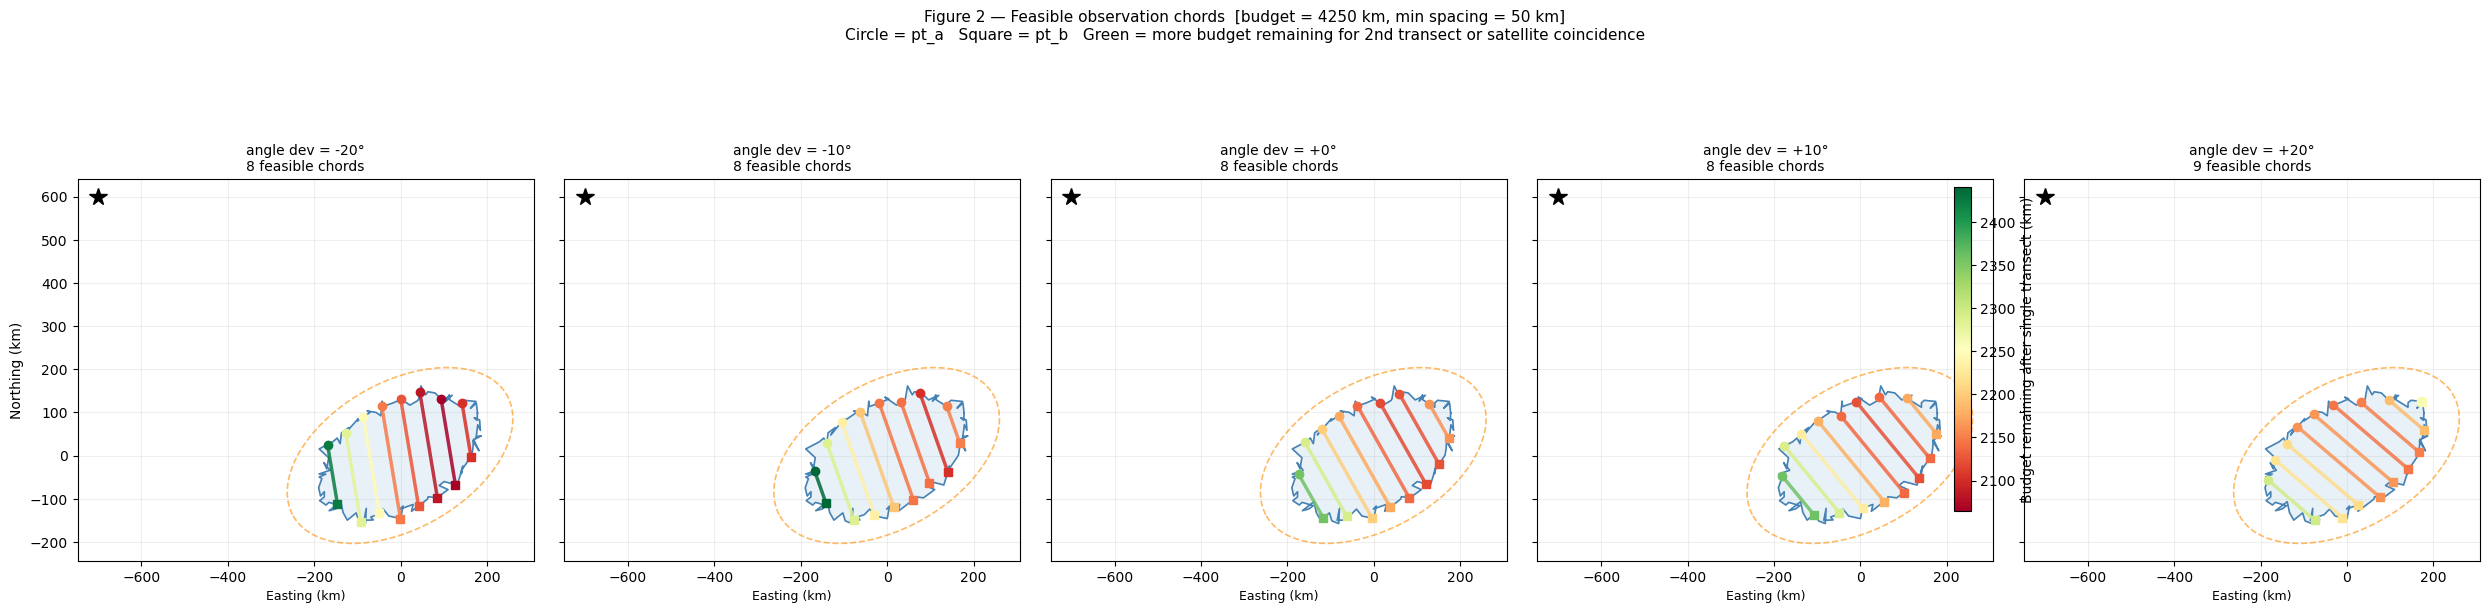

Central chord (offset ≈ 0, angle_dev = 0°):
  Chord length inside TPV : 196 km
  Single-trip distance    : 1958 km
  Remaining budget        : 2292 km
  → available for a 2nd transect or satellite coincidence


In [6]:
# ── Figure 2: Feasible chords, one panel per angle deviation ─────────────
all_rem = [c['budget_remaining'] for c in chords if c['feasible']]
norm    = plt.Normalize(min(all_rem), max(all_rem))
cmap    = plt.cm.RdYlGn

fig, axes = plt.subplots(1, N_ANGLE_SAMPLES, figsize=(5*N_ANGLE_SAMPLES, 7),
                          sharey=True)

closed_pts = np.vstack([TPV_PTS, TPV_PTS[0]])

for ax, dev in zip(axes, angle_devs):
    ax.fill(TPV_PTS[:,0], TPV_PTS[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
    ax.plot(closed_pts[:,0], closed_pts[:,1], color='steelblue', lw=1.2, zorder=2)
    ax.plot(ell_xy[:,0], ell_xy[:,1], '--', color='darkorange',
            lw=1.2, alpha=0.6, zorder=3)

    sub_feas = [c for c in chords if c['angle_dev'] == dev and c['feasible']]
    for c in sub_feas:
        col = cmap(norm(c['budget_remaining']))
        ax.plot([c['pt_a'][0], c['pt_b'][0]],
                [c['pt_a'][1], c['pt_b'][1]],
                '-', color=col, lw=2.5, alpha=0.85, zorder=4)
        ax.plot(*c['pt_a'], 'o', color=col, ms=6, zorder=5)
        ax.plot(*c['pt_b'], 's', color=col, ms=6, zorder=5)

    ax.plot(*BASE, '*', color='black', ms=13, zorder=7)
    ax.set_title(f'angle dev = {dev:+.0f}°\n{len(sub_feas)} feasible chords',
                 fontsize=10)
    ax.set_aspect('equal')
    ax.set_xlabel('Easting (km)', fontsize=9)
    ax.grid(True, alpha=0.2)

axes[0].set_ylabel('Northing (km)', fontsize=10)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
fig.colorbar(sm, ax=axes.tolist(),
             label='Budget remaining after single transect (km)',
             shrink=0.6, pad=0.01)

fig.suptitle(
    f'Figure 2 — Feasible observation chords  [budget = {TOTAL_BUDGET_KM:.0f} km, '
    f'min spacing = {MIN_LEG_SPACING_KM:.0f} km]\n'
    'Circle = pt_a   Square = pt_b   '
    'Green = more budget remaining for 2nd transect or satellite coincidence',
    fontsize=11)
plt.tight_layout()
plt.show()

if ideal_feas:
    central = ideal_feas[len(ideal_feas)//2]
    print(f'Central chord (offset ≈ 0, angle_dev = 0°):')
    print(f'  Chord length inside TPV : {central["length"]:.0f} km')
    print(f'  Single-trip distance    : {central["single_trip_dist"]:.0f} km')
    print(f'  Remaining budget        : {central["budget_remaining"]:.0f} km')
    print(f'  → available for a 2nd transect or satellite coincidence')